# Day 7 — Clustering: finding the market's own segments
### Real Estate Machine · Graduation Project

Every model so far has been **supervised**: you told the algorithm what the right answer was.
Today the algorithm gets no answer at all. It sees 3,476 houses described by their physical
characteristics and has to decide, on its own, which ones belong together.

This notebook has two jobs, and they pull in different directions:

1. **A business job.** An investment company cannot act on 4,345 individual houses. It can act on
   four segments with names. That is the deliverable Day 14 puts on a slide.
2. **A machine learning job.** The cluster label becomes the *target* for Day 8's classifier.

---

## The decision that shapes everything: which columns define a segment

`price` is excluded. So is everything computed from it — `price_per_sqft`, and the
target-encoded `zipcode`/`city` columns from Day 6, because those **are** average prices wearing a
different name.

The reason is not squeamishness about leakage. It is that clustering on price makes your own
findings circular:

> Build segments from price → discover that the expensive segment is expensive.

That is a tautology, and an examiner will say so. Build the segments from **what a house physically
is** — size, layout, age, condition, outlook — and price becomes an *independent check*. If four
groups defined without ever seeing a price turn out to have median prices of \$336k and \$850k, you
have found real market structure. That is a result. The other version is a mirror.

It also protects Days 8–10. A cluster label built from price, fed to a model that predicts price,
would quietly leak the target through the back door.

## 1. Setup

Same clean data, same engineered features, and — importantly — the **same train/test split** that
Day 6 wrote to disk.

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid")

DATA = Path("..") / "Data"
MODELS = Path("..") / "Models"
FIGS = Path("..") / "reports" / "figures"
MODELS.mkdir(exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

sys.path.append(str((Path("..") / "app").resolve()))
import preprocessing as P

df = P.engineer_features(pd.read_csv(DATA / "data_clean.csv", dtype={"zipcode": str}))

split = pd.read_csv(DATA / "split_indices.csv", index_col="row")["split"]
train_idx = split.index[split == "train"]
test_idx = split.index[split == "test"]
print(f"{df.shape[0]:,} houses  |  train {len(train_idx):,}  test {len(test_idx):,}")
print("Split reused from Day 6 — not re-drawn. Same rows, same experiment.")

4,345 houses  |  train 3,476  test 869
Split reused from Day 6 — not re-drawn. Same rows, same experiment.


---
## 2. The clustering feature set

Nine columns. Each one answers a question a buyer actually asks when they walk in.

| Feature | The question it answers |
|---|---|
| `log_sqft_living` | How big is it? |
| `log_sqft_lot` | How much land? |
| `bedrooms`, `bathrooms` | How many people does it hold, how comfortably? |
| `floors` | One-storey bungalow or two-storey house? |
| `house_age` | New build or period property? |
| `condition` | What state is it in? |
| `view` | What do you see out of the window? |
| `has_basement` | Is there below-grade space? |

Logs, not raw square feet: Day 3 showed both area columns are heavily right-skewed, and k-means
minimises *squared* distance. On the raw scale a single 13,540 sqft mansion pulls a centroid further
than a hundred ordinary houses combined, and you end up with a cluster of one.

**`waterfront` is left out.** Only 0.7% of houses have it — 29 rows. A feature that is zero for
99.3% of the data cannot define a segment; it just adds a dimension that is almost always zero. It
stays as a regression feature on Day 9, where a rare but powerful signal is exactly what a
tree-based model is good at.

In [2]:
CLUSTER_FEATURES = [
    "log_sqft_living", "log_sqft_lot", "bedrooms", "bathrooms",
    "floors", "house_age", "condition", "view", "has_basement",
]

# Explicit proof that nothing here descends from price.
forbidden = {"price", "price_per_sqft", "zipcode_te", "city_te"}
assert not (set(CLUSTER_FEATURES) & forbidden), "a price-derived column slipped in"
print("Clustering on", len(CLUSTER_FEATURES), "structural features. Price-free:", True)

X_all = df[CLUSTER_FEATURES]
X_tr = X_all.loc[train_idx]
X_tr.describe().T[["mean", "50%", "max"]]

Clustering on 9 structural features. Price-free: True


,mean,50%,max
log_sqft_living,7.57,7.59,9.21
log_sqft_lot,8.99,8.94,13.89
bedrooms,3.40,3.00,9.00
bathrooms,2.15,2.25,6.50
floors,1.51,1.50,3.50
house_age,43.51,39.00,114.00
condition,3.45,3.00,5.00
view,0.23,0.00,4.00
has_basement,0.40,0.00,1.00


### Scaling is not optional here

K-means measures straight-line distance. `sqft_lot` ranges over hundreds of thousands; `floors`
ranges from 1 to 3.5. Without standardising, the distance between two houses is essentially the
difference in their lot sizes, and every other column is decoration.

Fit the scaler on the **training rows only** — same rule as Day 6, same reason. Test houses get
*assigned* to segments later; they do not get a vote in where the segments are.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_tr)
Z_tr = scaler.transform(X_tr)

print("Scaled training matrix:", Z_tr.shape)
print("Column means ~0 :", np.abs(Z_tr.mean(axis=0)).max() < 1e-9)
print("Column sds   ~1 :", np.allclose(Z_tr.std(axis=0), 1))

Scaled training matrix: (3476, 9)
Column means ~0 : True
Column sds   ~1 : True


---
## 3. How many segments? Two pieces of evidence

**Inertia (the elbow).** Total squared distance from each house to its centroid. It *always* falls
as `k` rises — at `k = n` it reaches zero, with one cluster per house and nothing learned. So the
elbow is a judgement call about diminishing returns, not a measurement.

**Silhouette.** For each house: how much closer is it to its own cluster than to the nearest rival
cluster? Ranges from −1 to +1.

- ≈ 1 — sits comfortably inside its group
- ≈ 0 — sits on the border, could go either way
- < 0 — is probably in the wrong cluster

Silhouette is the stronger evidence because it can go **down** when `k` is wrong. Inertia cannot.

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z_tr)
    sizes = np.bincount(km.labels_)
    results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(Z_tr, km.labels_, sample_size=3000, random_state=42),
        "smallest_cluster": sizes.min(),
        "smallest_pct": 100 * sizes.min() / len(Z_tr),
    })

k_table = pd.DataFrame(results)

# Print with 4 decimals: the differences in silhouette across k are small, and
# rounding them to 2 decimals hides the very thing you are choosing on.
print(k_table.to_string(index=False, formatters={
    "inertia": "{:,.0f}".format, "silhouette": "{:.4f}".format,
    "smallest_pct": "{:.1f}%".format}))

 k inertia silhouette  smallest_cluster smallest_pct
 2  24,178     0.2388              1558        44.8%
 3  20,521     0.2418              1076        31.0%
 4  17,834     0.2547               269         7.7%
 5  15,961     0.2451               260         7.5%
 6  14,917     0.2385               250         7.2%
 7  13,960     0.2452               241         6.9%
 8  13,230     0.2286               240         6.9%


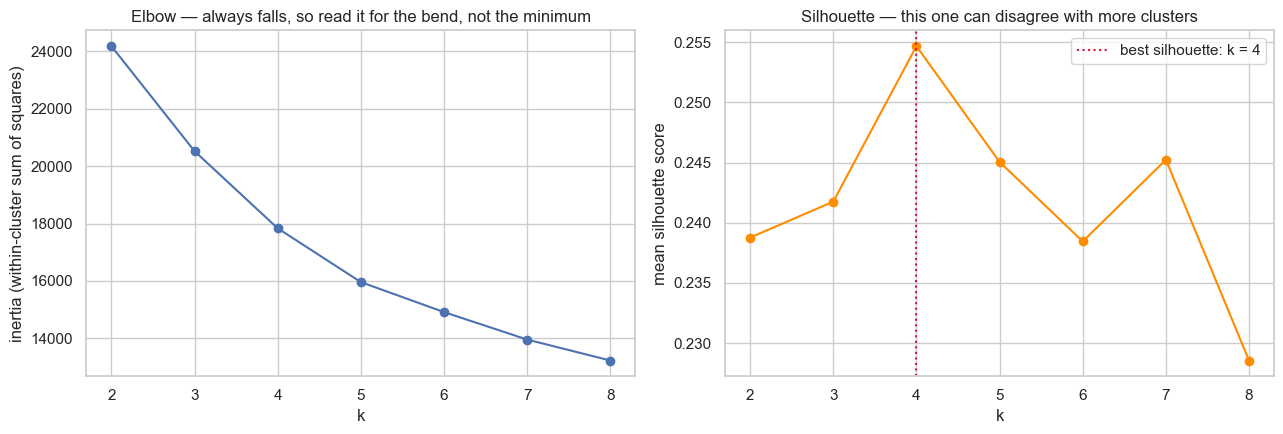

Highest silhouette at k = 4


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(k_table["k"], k_table["inertia"], marker="o")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia (within-cluster sum of squares)")
ax[0].set_title("Elbow — always falls, so read it for the bend, not the minimum")

ax[1].plot(k_table["k"], k_table["silhouette"], marker="o", color="darkorange")
best_k = int(k_table.loc[k_table["silhouette"].idxmax(), "k"])
ax[1].axvline(best_k, ls=":", c="crimson", lw=1.5, label=f"best silhouette: k = {best_k}")
ax[1].set_xlabel("k"); ax[1].set_ylabel("mean silhouette score")
ax[1].set_title("Silhouette — this one can disagree with more clusters")
ax[1].legend()

fig.tight_layout()
fig.savefig(FIGS / "06_k_selection.png", dpi=150)
plt.show()

print("Highest silhouette at k =", best_k)

### Choosing `k` — and being honest about the number

Three criteria, in this order:

1. **Silhouette** — take the peak.
2. **No tiny clusters** — a segment holding 2% of the market is a curiosity, not a business unit.
   Check the `smallest_pct` column.
3. **Explainability** — the roadmap caps this at 6 for a reason. If you cannot describe a segment in
   one sentence to a manager, it does not exist as far as the business is concerned.

Now the part most students skip. Look at the *absolute* silhouette value, not just where it peaks.
It will be somewhere around 0.25 — positive, so the structure is real, but nowhere near 1. Notice
too how little it moves between neighbouring values of `k`: the peak is a genuine best, not a
landslide, and you should present it that way.

Say this out loud in the defense before anyone asks:

> Houses do not come in four natural species. Size, bedrooms and bathrooms vary smoothly and
> continuously, so there are no empty gaps in the data for a clustering algorithm to find. A
> silhouette of ~0.25 tells me these are **useful summaries of a continuum**, not discovered
> categories. I chose k by silhouette and confirmed the segments are stable and interpretable; I am
> not claiming the market is genuinely made of four kinds of house.

A student who says that has understood clustering. A student who reports "silhouette 0.25" as
though it were an accuracy score has not.

In [6]:
K = best_k          # change this by hand if section 5's profiles argue for a different k
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Z_tr)

df["cluster"] = kmeans.predict(scaler.transform(X_all))
df["split"] = split.values

counts = df["cluster"].value_counts().sort_index()
print(f"k = {K}\n")
print(pd.DataFrame({"houses": counts, "share": (100 * counts / len(df)).round(1)}))

k = 4

         houses  share
cluster               
0          1180  27.20
1          1239  28.50
2           345   7.90
3          1581  36.40


### Why the test houses were *predicted*, not fitted

`kmeans.predict()` assigns each test house to the nearest existing centroid. The centroids
themselves were computed from training rows alone.

This matters on Day 8: the classifier will be trained to reproduce these labels. If the test labels
had been produced by a k-means that had already seen the test houses, the Day 8 test score would be
measuring nothing.

---
## 4. Stability — would a different random start give different segments?

K-means begins from randomly chosen centroids and converges to a *local* optimum. Different seeds
can converge somewhere else. If your four segments only exist because `random_state=42`, they are an
artefact and not a finding.

**Adjusted Rand Index** compares two labellings while ignoring the arbitrary label numbers:
1.0 = identical partitions, 0.0 = no more agreement than chance.

In [7]:
from sklearn.metrics import adjusted_rand_score

reference = kmeans.labels_
for seed in [0, 7, 99, 2024]:
    alt = KMeans(n_clusters=K, n_init=10, random_state=seed).fit_predict(Z_tr)
    print(f"seed {seed:>5}: ARI vs reference = {adjusted_rand_score(reference, alt):.3f}")

print("\nAnd a deliberately different k, for contrast:")
alt_k = KMeans(n_clusters=K + 1, n_init=10, random_state=42).fit_predict(Z_tr)
print(f"k = {K + 1}: ARI vs k = {K} solution = {adjusted_rand_score(reference, alt_k):.3f}")

seed     0: ARI vs reference = 1.000
seed     7: ARI vs reference = 1.000
seed    99: ARI vs reference = 1.000
seed  2024: ARI vs reference = 1.000

And a deliberately different k, for contrast:
k = 5: ARI vs k = 4 solution = 0.800


High ARI across seeds means the solution is reproducible — the segments are a property of the data,
not of the starting point. The `k+1` comparison is deliberately lower: adding a cluster splits an
existing group, which is what it *should* do.

---
## 5. What are these segments? The profile table

This is the most important output of the day. Everything else was method; this is the finding.

`price` and `price_per_sqft` appear here for the first time — as **description**, never as input.
They were not available to the algorithm.

In [8]:
profile = df.groupby("cluster").agg(
    houses=("price", "size"),
    sqft_living=("sqft_living", "median"),
    sqft_lot=("sqft_lot", "median"),
    bedrooms=("bedrooms", "median"),
    bathrooms=("bathrooms", "median"),
    floors=("floors", "median"),
    house_age=("house_age", "median"),
    condition=("condition", "mean"),
    view=("view", "mean"),
    has_basement=("has_basement", "mean"),
    median_price=("price", "median"),
    price_per_sqft=("price_per_sqft", "median"),
).round(2)

profile["has_basement"] = (100 * profile["has_basement"]).round(0).astype(int)
profile = profile.rename(columns={"has_basement": "basement_%"})
profile

,houses,sqft_living,sqft_lot,bedrooms,bathrooms,floors,house_age,condition,view,basement_%,median_price,price_per_sqft
cluster,,,,,,,,,,,,
0,1180,"2,090.00","8,250.00",4.00,2.00,1.00,52.00,3.77,0.03,92,"492,325.00",233.42
1,1239,"1,250.00","7,480.00",3.00,1.00,1.00,60.00,3.53,0.05,12,"336,500.00",279.50
2,345,"2,960.00","9,687.00",4.00,2.50,2.00,46.00,3.55,2.63,77,"850,000.00",299.28
3,1581,"2,400.00","7,089.00",4.00,2.50,2.00,13.00,3.12,0.01,17,"535,000.00",232.86


In [9]:
# Where each segment actually is on the map.
for c in sorted(df["cluster"].unique()):
    top = df.loc[df["cluster"] == c, "city"].value_counts(normalize=True).head(4)
    share = ", ".join(f"{city} {100 * p:.0f}%" for city, p in top.items())
    print(f"Cluster {c}: {share}")

Cluster 0: Seattle 40%, Bellevue 9%, Renton 5%, Kirkland 5%
Cluster 1: Seattle 44%, Renton 7%, Shoreline 5%, Auburn 5%
Cluster 2: Seattle 42%, Bellevue 9%, Mercer Island 7%, Renton 4%
Cluster 3: Seattle 21%, Issaquah 8%, Redmond 8%, Sammamish 7%


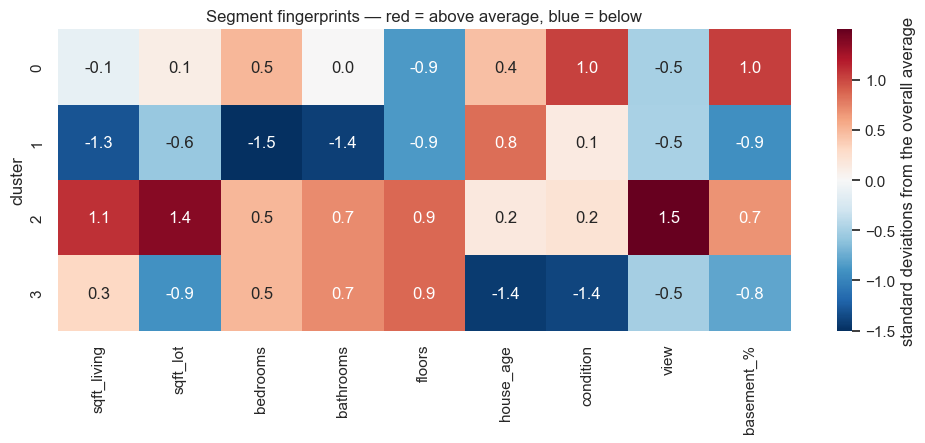

In [10]:
# A visual read of the same table: z-scored profile, so the columns are comparable.
prof_z = profile.drop(columns=["houses", "median_price", "price_per_sqft"])
prof_z = (prof_z - prof_z.mean()) / prof_z.std()

fig, ax = plt.subplots(figsize=(10, 3 + 0.4 * K))
sns.heatmap(prof_z, annot=True, fmt=".1f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "standard deviations from the overall average"})
ax.set_title("Segment fingerprints — red = above average, blue = below")
ax.set_ylabel("cluster")
fig.tight_layout()
fig.savefig(FIGS / "06_cluster_profiles.png", dpi=150)
plt.show()

---
## 6. Naming the segments

A cluster number means nothing to a manager. A name does.

The rules below read the profile table and pick a name for each segment. **Do not accept them
blindly** — check each one against the table above and rewrite any that does not fit. The rubric
grades whether you can interpret a result, and the fastest way to lose that mark is to present a
label you cannot justify from the numbers on the screen.

In [11]:
names, used = {}, set()

def claim(cluster_id, name):
    if cluster_id not in names and name not in used:
        names[cluster_id] = name
        used.add(name)

# 1. Best outlook -> the view premium segment.
claim(profile["view"].idxmax(), "Premium View Property")
# 2. Smallest homes -> where a first-time buyer or a rental investor shops.
claim(profile["sqft_living"].idxmin(), "Compact Entry-Level")
# 3. Youngest stock -> modern suburban development.
claim(profile["house_age"].idxmin(), "New-Build Suburban Family")
# 4. Whatever remains -> established housing stock.
for c in profile.index:
    claim(c, "Established Family Home")
for c in profile.index:                      # safety net if k > 4
    claim(c, f"Segment {c}")

df["segment"] = df["cluster"].map(names)

summary = profile.assign(segment=[names[c] for c in profile.index])[
    ["segment", "houses", "sqft_living", "bedrooms", "house_age",
     "view", "basement_%", "median_price", "price_per_sqft"]
]
summary

,segment,houses,sqft_living,bedrooms,house_age,view,basement_%,median_price,price_per_sqft
cluster,,,,,,,,,
0,Established Family Home,1180,"2,090.00",4.00,52.00,0.03,92,"492,325.00",233.42
1,Compact Entry-Level,1239,"1,250.00",3.00,60.00,0.05,12,"336,500.00",279.50
2,Premium View Property,345,"2,960.00",4.00,46.00,2.63,77,"850,000.00",299.28
3,New-Build Suburban Family,1581,"2,400.00",4.00,13.00,0.01,17,"535,000.00",232.86


**Now write one sentence per segment in your own words**, in a markdown cell right below this one.
The shape you are aiming for — check every number against your own table before you use it:

- **Compact Entry-Level** — small, older, single-storey homes. The cheapest total price in the
  market, but *not* the cheapest per square foot: buyers pay a premium for the smallest units.
  This is where entry-level and rental demand sits.
- **Established Family Home** — mid-sized, older houses, almost all with a basement. The volume
  segment of the market.
- **New-Build Suburban Family** — the youngest stock, two storeys, rarely a basement, concentrated
  in the eastern suburbs. Modern layouts, newer neighbourhoods.
- **Premium View Property** — the largest houses with the best outlook and the highest median price.
  The smallest segment by count.

The price-per-square-foot column is the one worth pausing on, because it does **not** simply rise
with price. Explaining why is a stronger answer than any silhouette score.

---
## 7. Validation — price was never an input, so it gets to be a test

If segments built purely from physical characteristics show large, systematic differences in price,
the segmentation has captured something real about the market.

In [12]:
from scipy import stats

groups = [g["price"].values for _, g in df.groupby("cluster")]
h_stat, p_val = stats.kruskal(*groups)

print(f"Kruskal-Wallis H = {h_stat:,.1f},  p = {p_val:.3g}")
print("Median price by segment:")
for c in profile.index:
    print(f"  {names[c]:<28} ${profile.loc[c, 'median_price']:>10,.0f}")
spread = profile["median_price"].max() / profile["median_price"].min()
print(f"\nTop segment is {spread:.1f}x the median price of the bottom segment.")

Kruskal-Wallis H = 1,009.1,  p = 1.94e-218
Median price by segment:
  Established Family Home      $   492,325
  Compact Entry-Level          $   336,500
  Premium View Property        $   850,000
  New-Build Suburban Family    $   535,000

Top segment is 2.5x the median price of the bottom segment.


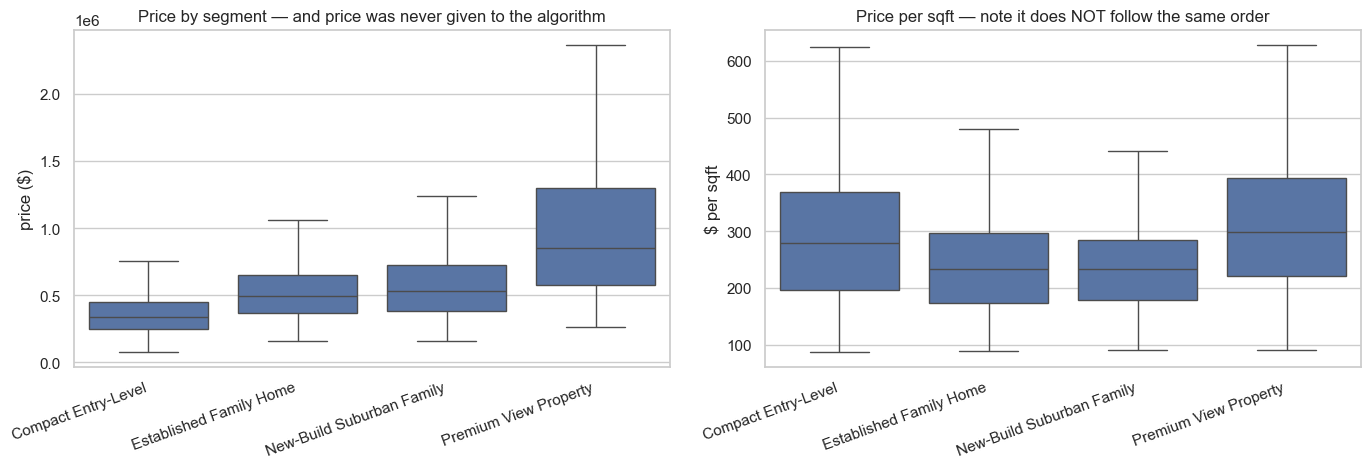

In [13]:
order = profile["median_price"].sort_values().index
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="cluster", y="price", order=order, showfliers=False, ax=ax[0])
ax[0].set_title("Price by segment — and price was never given to the algorithm")
ax[0].set_xticklabels([names[c] for c in order], rotation=20, ha="right")
ax[0].set_ylabel("price ($)"); ax[0].set_xlabel("")

sns.boxplot(data=df, x="cluster", y="price_per_sqft", order=order, showfliers=False, ax=ax[1])
ax[1].set_title("Price per sqft — note it does NOT follow the same order")
ax[1].set_xticklabels([names[c] for c in order], rotation=20, ha="right")
ax[1].set_ylabel("$ per sqft"); ax[1].set_xlabel("")

fig.tight_layout()
fig.savefig(FIGS / "06_price_by_segment.png", dpi=150)
plt.show()

A caveat to state before an examiner does: a Kruskal-Wallis test on 4,345 houses will return a tiny
p-value for almost any grouping. The p-value says "these medians are not identical" — which was
never in doubt. **The effect size is the evidence**: a multiple-fold gap between the top and bottom
segment medians, from a model that never saw a price.

---
## 8. Seeing the clusters — PCA to two dimensions

Nine dimensions cannot be drawn. PCA finds the two directions along which the houses vary most and
projects everything onto that plane.

Two honest warnings:

- The two components will capture only part of the total variance — print the number and quote it.
  Clusters that overlap in the picture may be cleanly separated along a direction that was thrown
  away.
- PCA is used **for the picture only**. K-means ran on all nine standardised features. Clustering on
  PCA output is a different method with different results, and conflating the two is a common
  mistake.

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42).fit(Z_tr)
coords = pca.transform(scaler.transform(X_all))
ev = pca.explained_variance_ratio_
print(f"PC1 {ev[0]:.1%} + PC2 {ev[1]:.1%} = {ev.sum():.1%} of total variance retained")

loadings = pd.DataFrame(pca.components_.T, index=CLUSTER_FEATURES, columns=["PC1", "PC2"])
print("\nWhat the two axes actually mean (loadings):")
loadings.round(2)

PC1 32.7% + PC2 20.9% = 53.5% of total variance retained

What the two axes actually mean (loadings):


,PC1,PC2
log_sqft_living,0.52,0.20
log_sqft_lot,0.15,0.29
bedrooms,0.40,0.25
bathrooms,0.52,0.03
floors,0.34,-0.40
house_age,-0.34,0.41
condition,-0.14,0.43
view,0.15,0.29
has_basement,0.07,0.47


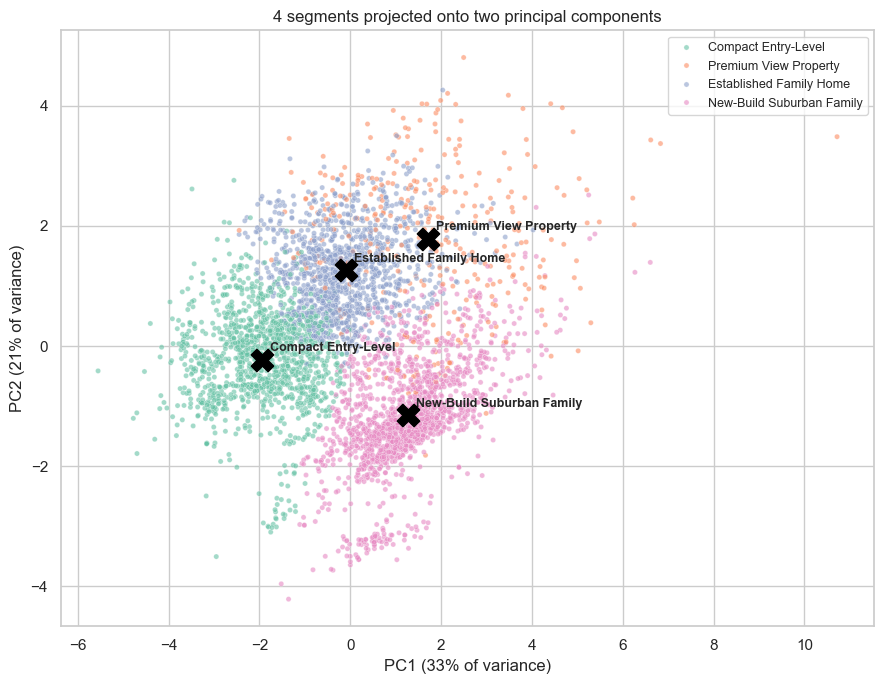

In [15]:
plot_df = pd.DataFrame(coords, columns=["PC1", "PC2"], index=df.index)
plot_df["segment"] = df["segment"]

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="segment", s=14, alpha=0.6,
                palette="Set2", ax=ax)

centres = pca.transform(kmeans.cluster_centers_)
ax.scatter(centres[:, 0], centres[:, 1], marker="X", s=260, c="black", zorder=5)
for c, (x, y) in zip(range(K), centres):
    ax.annotate(names[c], (x, y), fontsize=9, fontweight="bold",
                xytext=(6, 6), textcoords="offset points")

ax.set_xlabel(f"PC1 ({ev[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({ev[1]:.0%} of variance)")
ax.set_title(f"{K} segments projected onto two principal components")
ax.legend(title="", loc="best", fontsize=9)
fig.tight_layout()
fig.savefig(FIGS / "06_pca_clusters.png", dpi=150)
plt.show()

Read the loadings table before you interpret the picture. Typically PC1 is a **size** axis
(everything to do with area, bedrooms and bathrooms loading the same way) and PC2 separates
**old-with-basement** from **new-two-storey**. Naming your axes turns a coloured scatter plot into
an explanation.

---
## 9. Save everything Day 8 needs

In [16]:
from sklearn.pipeline import Pipeline

joblib.dump(kmeans, MODELS / "kmeans.pkl")
joblib.dump(scaler, MODELS / "cluster_scaler.pkl")
joblib.dump(Pipeline([("scale", scaler), ("kmeans", kmeans)]), MODELS / "cluster_pipeline.pkl")
joblib.dump({"k": K, "features": CLUSTER_FEATURES, "names": names,
             "silhouette": float(k_table.loc[k_table.k == K, "silhouette"].iloc[0]),
             "random_state": 42},
            MODELS / "cluster_config.pkl")

out = df.drop(columns=[c for c in ["date"] if c in df.columns])
out.to_csv(DATA / "data_clustered.csv", index=False)

print("Saved:")
for f in sorted(MODELS.glob("*.pkl")):
    print(f"  {f.name:<24} {f.stat().st_size / 1024:6.1f} KB")
print(f"  data_clustered.csv       {out.shape[0]:,} x {out.shape[1]}")

Saved:
  classifier.pkl              2.2 KB
  classifier_config.pkl       0.5 KB
  cluster_config.pkl          0.4 KB
  cluster_pipeline.pkl       15.5 KB
  cluster_scaler.pkl          1.1 KB
  feature_config.pkl          0.5 KB
  kmeans.pkl                 14.6 KB
  preprocessor.pkl            5.5 KB
  reference_stats.pkl         2.5 KB
  regression_baseline.pkl     5.9 KB
  regression_config.pkl       0.6 KB
  regressor.pkl             757.0 KB
  regressor_config.pkl        1.1 KB
  scaler.pkl                  1.5 KB
  shap_background.pkl        31.8 KB
  data_clustered.csv       4,345 x 30


In [17]:
# The Day 12 contract again: one house in, one segment out.
one_house = pd.DataFrame([{
    "bedrooms": 3, "bathrooms": 2.0, "sqft_living": 1800, "sqft_lot": 7500,
    "floors": 1.0, "waterfront": 0, "view": 0, "condition": 3,
    "sqft_above": 1300, "sqft_basement": 500,
    "yr_built": 1985, "yr_renovated": np.nan,
    "city": "Seattle", "zipcode": "98115",
}])

pipe = joblib.load(MODELS / "cluster_pipeline.pkl")
label = int(pipe.predict(P.engineer_features(one_house)[CLUSTER_FEATURES])[0])
print(f"Segment: {label} — {names[label]}")

Segment: 0 — Established Family Home


---
## 10. Deliverables & defense prep

**Produced today**

- `Notebooks/06_clustering.ipynb`
- `Models/kmeans.pkl`, `cluster_scaler.pkl`, `cluster_pipeline.pkl`, `cluster_config.pkl`
- `Data/data_clustered.csv` — carries `cluster`, `segment` and `split`; Day 8 starts from this file
- `reports/figures/06_k_selection.png`, `06_cluster_profiles.png`, `06_price_by_segment.png`,
  `06_pca_clusters.png`

**Commit**

```powershell
git add . && git commit -m "Day 7: k-means segmentation, k chosen by silhouette, profiles named"
```

**Defense questions**

1. *"Why k = 4 and not 5?"* — Three reasons, in this order. Silhouette is highest at 4 and k = 5
   does not improve it. The k = 5 solution has ARI ≈ 0.8 against the k = 4 one, meaning it mostly
   splits an existing group rather than revealing a new kind of house. And four segments are four
   things a manager can act on. Add the honest qualifier: the silhouette differences between
   neighbouring values of k are small, so k = 4 is the best-supported choice, not an obvious one.
2. *"Your silhouette is only ~0.25. Isn't that bad?"* — Section 3. Houses vary continuously, so
   there are no natural gaps to find. These are useful summaries of a continuum, and I am not
   claiming otherwise. Positive silhouette plus high seed-to-seed ARI is what makes them usable.
3. *"Why didn't you cluster on price? It's the most important variable."* — Section 0. Segments
   built from price make every price finding circular, and the label would leak the target into
   Days 8–10. Excluding it turned price into an independent validation instead.
4. *"How do you know the segments aren't a random artefact?"* — Section 4: ARI across four seeds,
   plus the profile table, where each segment differs on characteristics that were never used to
   create it.
5. *"What does PC1 mean?"* — Section 8 loadings. Do not present the scatter plot without this.

**A note for tomorrow.** Day 8 trains a classifier to predict these labels from the same features
that produced them. Expect accuracy above 95% — that is a *geometry* result, not a modelling
achievement, and the number must be presented with that caveat attached. The honesty is worth more
marks than the accuracy.